In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [5]:
df = df[df['room_type'] == 'Entire home/apt']

In [6]:
df['host_is_superhost'].info()

<class 'pandas.core.series.Series'>
Index: 17362 entries, 0 to 26580
Series name: host_is_superhost
Non-Null Count  Dtype 
--------------  ----- 
17362 non-null  object
dtypes: object(1)
memory usage: 271.3+ KB


In [7]:
df['price'] = df['price'].astype(float)

In [8]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_53772\1234139552.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


C:\Users\issei\AppData\Local\Temp\ipykernel_53772\3302511951.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


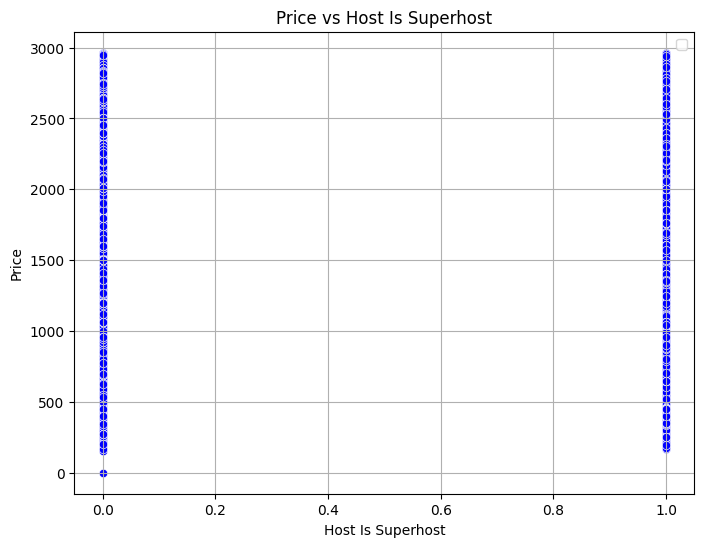

In [9]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='price', x='host_is_superhost',  color = 'blue', data=df)
plt.title('Price vs Host Is Superhost')
plt.xlabel('Host Is Superhost')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
indep= df[['host_is_superhost']]
dep = df[['price']]

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [12]:
model.fit(indep, dep)

LinearRegression()

In [13]:
type(model)

sklearn.linear_model._base.LinearRegression

In [14]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[49.19741989]]),
 'rank_': 1,
 'singular_': array([65.07015522]),
 'intercept_': array([1215.40108234])}

In [15]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[49.19741989]]
Intercepto: [1215.40108234]
y = [49.19741989]x + [1215.40108234]


In [16]:
r2 = model.score(indep, dep)
r2

0.0019512193772951436

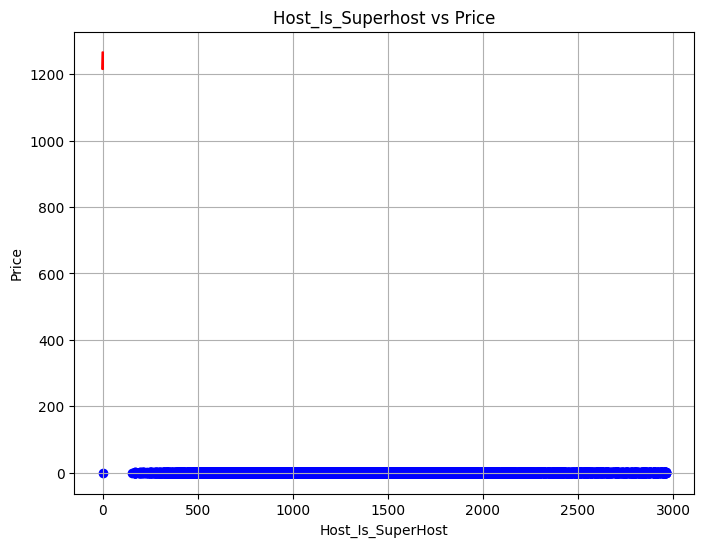

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('Host_Is_Superhost vs Price')
plt.xlabel('Host_Is_SuperHost')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [18]:
yPred = model.predict(df[['host_is_superhost']])
yPred

array([[1264.59850223],
       [1264.59850223],
       [1264.59850223],
       ...,
       [1215.40108234],
       [1215.40108234],
       [1264.59850223]])

In [19]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41,1264.598502
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31,1264.598502
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83,1264.598502
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11,1264.598502
5,6,165772,790208,10,5,city scrape,BEST 5 Bedroom HOUSE IN S. Miguel Chapultepec,Welcome to Your Home in Mexico City<br />We ha...,San Miguel Chapultepec is the best kept secret...,Francisco Carlos,...,0.0,4.88,4.91,4.84,4.92,4.90,4.75,4.90,2.23,1264.598502


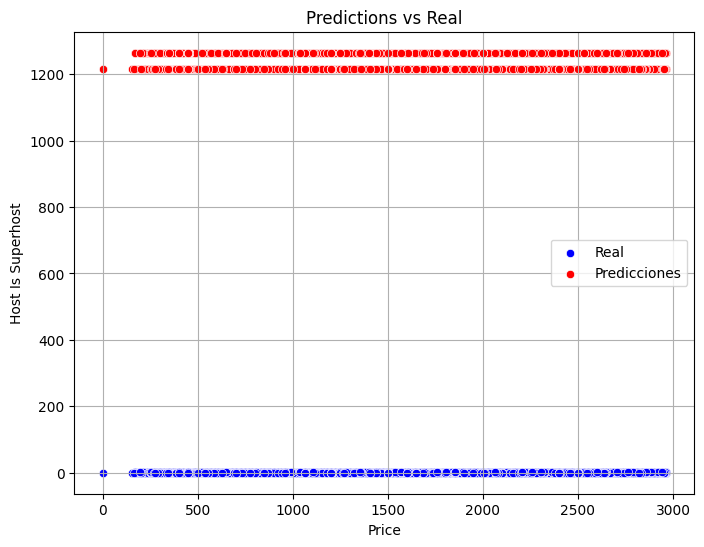

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='price', y='host_is_superhost', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('Host Is Superhost')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
coefDe = model.score(indep, dep)
coefDe

0.0019512193772951436

In [22]:
coefCo = np.sqrt(coefDe)
coefCo

0.04417260890297452